In [1]:
# ===== Bibliotecas utilizadas ===== #
# Para manipulação de imagens
import cv2
# Para manipulação de matrizes
import numpy as np 
# Para exibir as imagens
import matplotlib.pyplot as plt

In [2]:
# ===== Área das constantes ===== #
# Máscara do Realce Laplaciano
maskA = np.array(
    [[0,  1, 0],
     [1, -4, 1],
     [0,  1, 0]]).astype(np.int16)
# Máscara do Realce Laplaciano considerando as bordas
maskB = np.array(
    [[1,  1, 1],
     [1, -8, 1],
     [1,  1, 1]]).astype(np.int16)

In [3]:
# Função para cortar os valores fora do intervalo [0, 255]
def cut(image):
    return np.clip(image, 0, 255).astype(np.uint8)

In [4]:
# Função para normalizar os valores dos pixel entre 0 e 255
def map(image):
    # Separando os canais de cores
    blue, green, red = cv2.split(image)
    # Pegando o máximo e mínimo de cada canal
    maximum = np.array([np.max(blue), np.max(green), np.max(red)])
    minimum = np.array([np.min(blue), np.min(green), np.min(red)])
    # Realizando a normalização
    return (255.0 * (image - minimum) / (maximum - minimum)).astype(np.uint8)

In [5]:
# Função principal
def main():
    # Lista de imagens
    images = [] 
    # Lendo a imagem original
    images.append(cv2.imread("./images/a.tif"))
    # Trocando o range da imagem A de uint8 para int16
    images[0] = images[0].astype(np.int16)

    # Criando as outras imagens (B, C, D, E)
    for i in range(1, 5):
        images.append(np.zeros(images[0].shape))

    # Iniciando a imagem D e E como uma cópia da A
    images[3] = images[0].copy()
    images[4] = images[0].copy()

    # Pegando as dimensões da imagem A
    height = images[0].shape[0]
    width = images[0].shape[1]

    # Separando o canal da imagem A
    blue, green, red = cv2.split(images[0])
    
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            # Submatriz de cada canal com dimensão 3 x 3 centrada em (i, j)
            submatrixBlue = blue[i - 1:i + 2, j - 1:j + 2]
            submatrixGreen = green[i - 1:i + 2, j - 1:j + 2]
            submatrixRed = red[i - 1:i + 2, j - 1:j + 2]  
            # Aplicação do laplaciano A em cada canal de cor
            blueValue = np.sum(submatrixBlue * maskA)
            greenValue = np.sum(submatrixGreen * maskA)
            redValue = np.sum(submatrixRed * maskA)
            # Juntando os canais em um array
            auxiliary = [blueValue, greenValue, redValue]
            # Criando as imagens B, C, D
            images[1][i][j] = auxiliary
            images[2][i][j] = auxiliary 
            images[3][i][j] -= auxiliary
            # Aplicação do laplaciano B em cada canal de cor
            blueValue = np.sum(submatrixBlue * maskB)    
            greenValue = np.sum(submatrixGreen * maskB)    
            redValue = np.sum(submatrixRed * maskB)
            # Juntando os canais em um array
            auxiliary = [blueValue, greenValue, redValue]
            # Criando a imagem E
            images[4][i][j] -= auxiliary

    # Normalizando a imagem C no intervalo [0, 255]
    images[2] = map(images[2])
    # Cortando os valores negativos da imagem
    images[3] = cut(images[3])
    images[4] = cut(images[4])

    # Realizando o plot das imagens
    for i in range(5):
        images[i] = images[i].astype(np.uint8)
        cv2.imwrite(f"./images/{chr(ord('a') + i)}.jpg", images[i])
        images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

    # Criando uma matriz 2 x 3 para o plot
    fig, axs = plt.subplots(2, 3, figsize = (16, 13)) 
    
    # Organizando as imagens na matriz 2 x 3 do plot
    for i in range(2):
        for j in range(3):
            if i != 1 or j != 2:
                axs[i][j].imshow(images[3 * i + j])
                axs[i][j].set_title(chr(ord('A') + 3 * i + j))
    # Retirando o que seria a imagem F do plot
    fig.delaxes(axs[1][2])
    
    # Evitando sobreposição das imagens no plot
    plt.tight_layout()
    # Salvando um cópia do plot
    fig.savefig('moons.png', dpi = 300, bbox_inches = 'tight') 
    # Exibindo o plot
    plt.show()

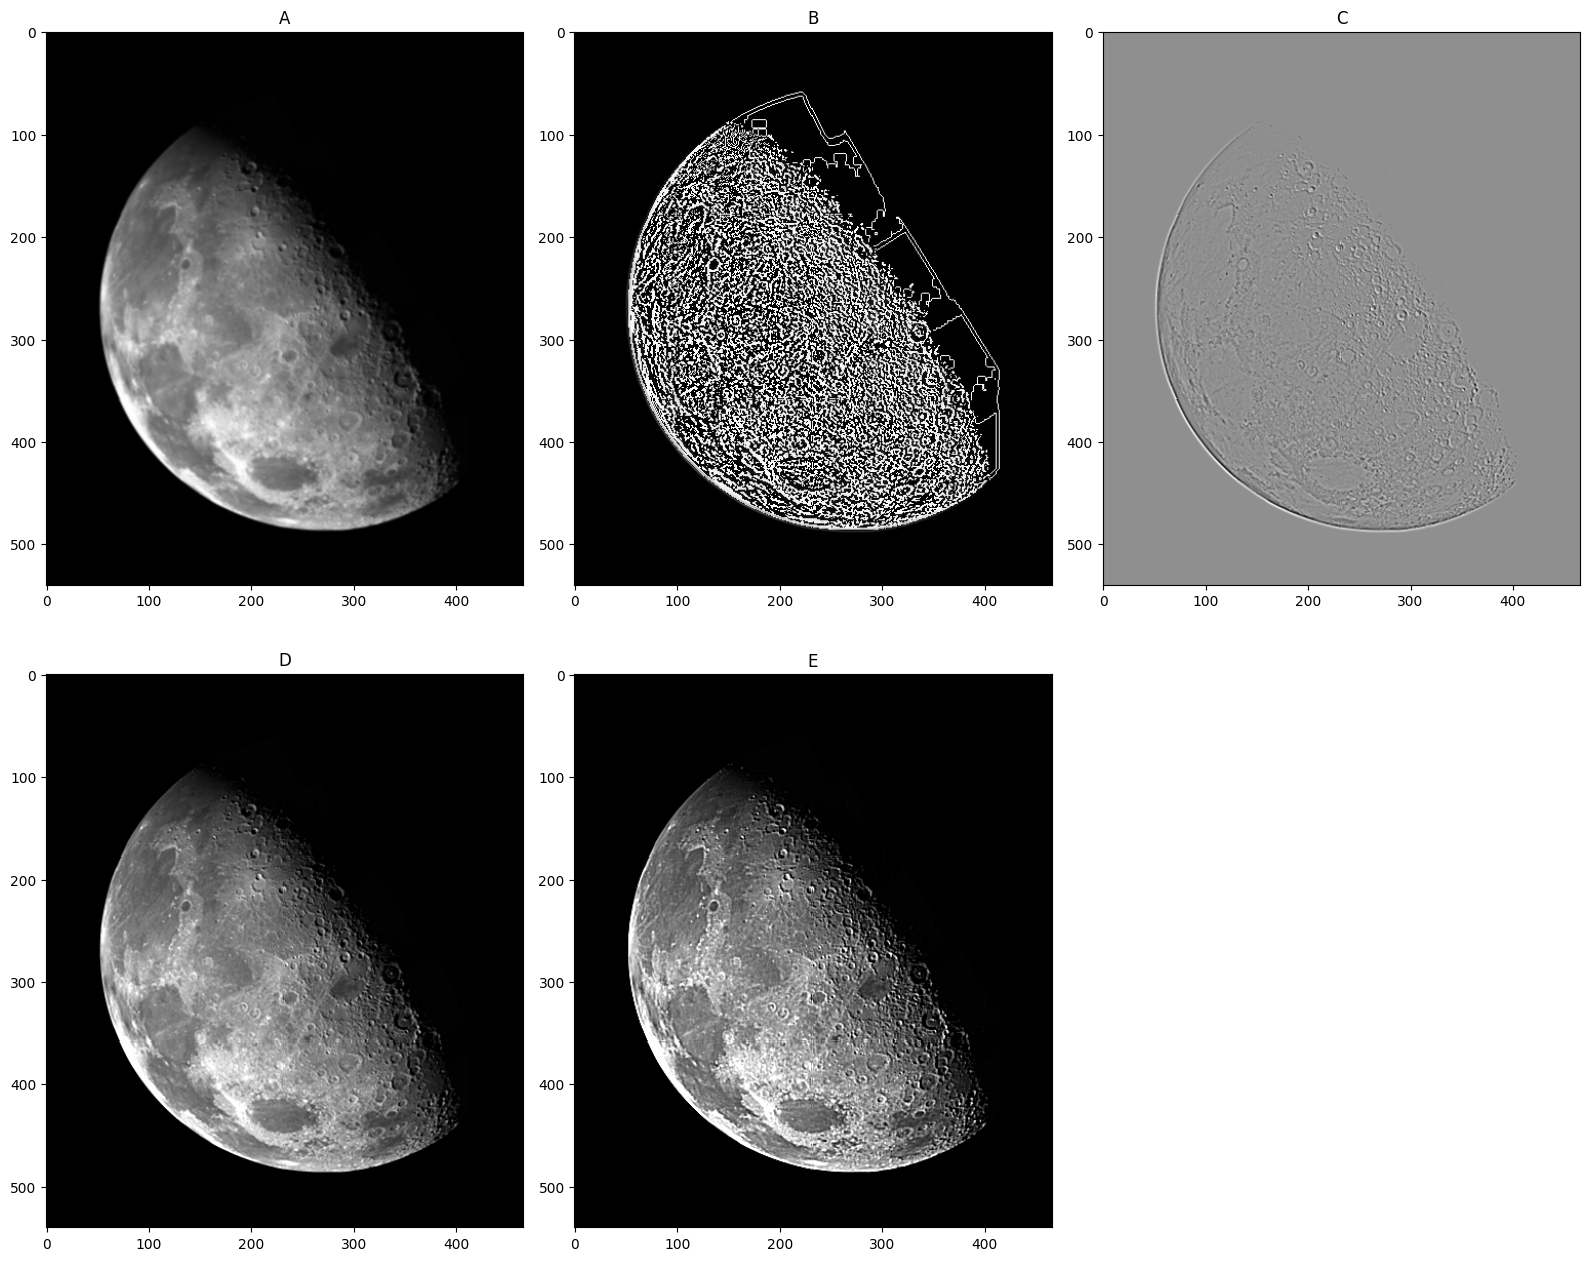

In [6]:
# Chamada da função principal
main()